In [1]:
from atomica.models import MultiClassClassifierModel, MultiLabelClassifierModel, ResidueClassifierModel
from atomica.data.dataset import MultiClassLabelledPDBDataset, LabelledPDBDataset, PocketEmbeddingDatasetWrapper
from atomica.trainers import Trainer

from multiclass_metrics import compute_multiclass_metrics
from multilabel_metrics import compute_multilabel_metrics

from torch.utils.data import DataLoader
import torch
from tqdm import tqdm
import numpy as np
import pandas as pd
import json
import os
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from glob import glob

MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/"
DATA_DIR="/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks"

/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
def get_model(model_checkpoint: str, task_name: str) -> str:
    model_config = os.path.join(os.path.dirname(model_checkpoint), "config.json")
    if task_name == "RNAGo":
        return MultiLabelClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Ligand":
        return MultiClassClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    elif task_name == "RNA_Protein" or task_name == "RNA_Site":
        return ResidueClassifierModel.load_from_config_and_weights(model_config, model_checkpoint)
    else:
        raise ValueError(f"Task name {task_name} not supported")

def predict_with_thresholds(proba, class_thresholds):
    """Helper function to predict using class-specific thresholds."""
    proba = np.array(proba)
    # Check which classes exceed their thresholds
    above_threshold = np.array([proba[i] >= class_thresholds.get(i, 0.0) for i in range(len(proba))])
    
    if np.sum(above_threshold) == 1:
        # Exactly one class exceeds threshold
        return np.argmax(above_threshold)
    elif np.sum(above_threshold) > 1:
        # Multiple classes exceed thresholds, pick the one with highest probability
        candidates = np.where(above_threshold)[0]
        return candidates[np.argmax(proba[candidates])]
    else:
        # No class exceeds threshold, fallback to argmax
        return np.argmax(proba)

def get_atomica_results(model_checkpoint, task_name, split="val", threshold=0.5, class_thresholds=None, recompute=False, pocket_embeddings_file=None):
    if not recompute and os.path.exists(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet")):
        df = pd.read_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
        if class_thresholds is not None and task_name == "RNA_Ligand":
            # Convert class_thresholds to dict if it's a list
            if isinstance(class_thresholds, (list, np.ndarray)):
                class_thresholds = {i: float(t) for i, t in enumerate(class_thresholds)}
            
            df['pred'] = df['pred_probability'].apply(
                lambda x: predict_with_thresholds(x, class_thresholds)
            )
        if 'ckpt' in df.columns and df['ckpt'].iloc[0] == model_checkpoint or df['ckpt'].iloc[0] == model_checkpoint.replace(".ckpt", ".pt"):
            return df
    
    dataset = MultiClassLabelledPDBDataset(f"{DATA_DIR}/{task_name}/{task_name}_{split}_processed_RNA.parquet")
    model = get_model(model_checkpoint, task_name)

    # Validate pocket embeddings configuration
    is_residue_task = task_name in ["RNA_Protein", "RNA_Site"]
    model_expects_pocket_emb = hasattr(model, 'pocket_embedding_size') and model.pocket_embedding_size is not None
    
    if is_residue_task and pocket_embeddings_file is not None:
        raise ValueError(f"Task {task_name} is a residue-level task and does not support pocket embeddings")
    
    if model_expects_pocket_emb and pocket_embeddings_file is None:
        raise ValueError(
            f"Model was trained with pocket embeddings (embedding_size={model.pocket_embedding_size}) "
            f"but no pocket_embeddings_file was provided. Please provide the embeddings file."
        )
    
    if not model_expects_pocket_emb and pocket_embeddings_file is not None:
        print(f"Warning: Model was trained without pocket embeddings but pocket_embeddings_file was provided. "
              f"Ignoring pocket embeddings file.")
        pocket_embeddings_file = None
    
    # Wrap dataset with pocket embeddings if needed
    if pocket_embeddings_file is not None:
        print(f"Loading pocket embeddings from {pocket_embeddings_file}")
        dataset = PocketEmbeddingDatasetWrapper(dataset, pocket_embeddings_file)

    model.eval()
    model.to("cuda")
    batch_size = 1

    atomica_preds_run = []
    # Use the dataset's collate_fn to ensure pocket embeddings are properly handled
    collate_fn = dataset.collate_fn if hasattr(dataset, 'collate_fn') else MultiClassLabelledPDBDataset.collate_fn
    for i in tqdm(range(0, len(dataset), batch_size), total=len(dataset) // batch_size, desc="Running inference"):
        with torch.no_grad():
            batch = [dataset[j] for j in range(i, min(i+batch_size, len(dataset)))]
            batch = collate_fn(batch)
            batch = Trainer.to_device(batch, "cuda")
            atomica_preds_run.append(model.infer(batch).cpu().numpy())
    atomica_preds = np.concatenate(atomica_preds_run)

    # Get the underlying dataset data (handle wrapped datasets)
    if hasattr(dataset, 'base_dataset'):
        dataset_data = dataset.base_dataset.data
    else:
        dataset_data = dataset.data

    if task_name == "RNA_Protein":
        atomica_labels = np.concatenate([x['label'] for x in dataset_data])
        atomica_ids = sum([[x['id']] * len(x['label']) for x in dataset_data], [])
        atomica_preds = atomica_preds.flatten()
    elif task_name == "RNA_Site":
        atomica_labels = np.concatenate([x['label'] for x in dataset_data])
        atomica_preds = atomica_preds.flatten()
        atomica_ids = []
        for x in dataset_data:
            assert len(x['label']) == len(x['block_to_pdb_indexes'])
            for _, pdb_index in sorted(x['block_to_pdb_indexes'].items()):
                atomica_ids.append(x['id'] + '_' + str(pdb_index))
    else:
        atomica_labels = np.array([x['label'] for x in dataset_data])
        atomica_ids = np.array([x['id'] for x in dataset_data])
        atomica_labels = list(atomica_labels)
        atomica_preds = list(atomica_preds)
    atomica_results = pd.DataFrame({
        'id': atomica_ids,
        'label': atomica_labels,
        'pred_probability': atomica_preds,
    })
    if task_name == "RNA_Ligand":
        if class_thresholds is not None:
            # Convert class_thresholds to dict if it's a list
            if isinstance(class_thresholds, (list, np.ndarray)):
                class_thresholds = {i: float(t) for i, t in enumerate(class_thresholds)}
            
            atomica_results['pred'] = atomica_results['pred_probability'].apply(
                lambda x: predict_with_thresholds(x, class_thresholds)
            )
        else:
            atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: np.argmax(x))
    elif task_name == "RNAGo":
        atomica_results['pred'] = atomica_results['pred_probability'].apply(lambda x: (x > threshold).astype(int))
    else:
        atomica_results['pred'] = (atomica_results['pred_probability'] > threshold).astype(int)

    atomica_results['ckpt'] = model_checkpoint
    atomica_results.to_parquet(os.path.join(os.path.dirname(model_checkpoint), f"{split}_atomica_results.parquet"))
    return atomica_results

def find_optimal_class_thresholds(val_results, labels=[0, 1, 2], metric='f1_macro', n_thresholds=10, optimize_jointly=True):
    """
    Find optimal class-specific thresholds using validation set.
    
    Parameters:
    -----------
    val_results : pd.DataFrame
        Validation results with 'pred_probability' and 'label' columns
    labels : list
        List of class labels
    metric : str
        Metric to optimize ('f1_macro', 'f1_weighted', 'f1_micro')
    n_thresholds : int
        Number of threshold values to test per class
    optimize_jointly : bool
        If True, optimize all thresholds jointly (slower but better).
        If False, optimize each class threshold independently (faster).
        
    Returns:
    --------
    dict : Optimal thresholds for each class {class_idx: threshold}
    """
    y_true = np.stack(val_results['label'])
    y_proba = np.stack(val_results['pred_probability'])
    
    if optimize_jointly:
        # Joint optimization: test all combinations (more accurate but slower)
        thresholds = np.linspace(0.05, 0.95, n_thresholds)
        best_thresholds = {i: 0.05 for i in labels}
        best_score = 0.0
        
        # For efficiency, we'll do a coarse grid search
        # Test all combinations of thresholds
        from itertools import product
        
        print(f"Optimizing thresholds jointly (testing {n_thresholds**len(labels)} combinations)...")
        threshold_combinations = list(product(thresholds, repeat=len(labels)))
        
        for thresh_combo in tqdm(threshold_combinations, desc="Testing threshold combinations"):
            class_thresholds = {labels[i]: float(thresh_combo[i]) for i in range(len(labels))}
            
            # Make predictions using these thresholds
            preds = np.array([predict_with_thresholds(proba, class_thresholds) for proba in y_proba])
            
            # Compute metric
            if metric == 'f1_macro':
                score = f1_score(y_true, preds, average='macro', zero_division=0)
            elif metric == 'f1_weighted':
                score = f1_score(y_true, preds, average='weighted', zero_division=0)
            elif metric == 'f1_micro':
                score = f1_score(y_true, preds, average='micro', zero_division=0)
            else:
                raise ValueError(f"Unknown metric: {metric}")
            
            if score > best_score:
                best_score = score
                best_thresholds = class_thresholds.copy()
        
        print(f"Best {metric}: {best_score:.4f}")
        print(f"Optimal thresholds: {best_thresholds}")
        return best_thresholds
    
    else:
        # Independent optimization: optimize each class separately (faster)
        optimal_thresholds = {}
        
        for class_idx in labels:
            thresholds = np.linspace(0.05, 0.95, n_thresholds)
            best_threshold = 0.05
            best_score = 0.0
            
            # Use default thresholds for other classes (0.0) while optimizing this one
            default_thresholds = {i: 0.05 for i in labels}
            
            for threshold in tqdm(thresholds, desc=f"Optimizing threshold for class {class_idx}"):
                class_thresholds = default_thresholds.copy()
                class_thresholds[class_idx] = threshold
                
                # Make predictions using these thresholds
                preds = np.array([predict_with_thresholds(proba, class_thresholds) for proba in y_proba])
                
                # Compute metric
                if metric == 'f1_macro':
                    score = f1_score(y_true, preds, average='macro', zero_division=0)
                elif metric == 'f1_weighted':
                    score = f1_score(y_true, preds, average='weighted', zero_division=0)
                elif metric == 'f1_micro':
                    score = f1_score(y_true, preds, average='micro', zero_division=0)
                else:
                    raise ValueError(f"Unknown metric: {metric}")
                
                if score > best_score:
                    best_score = score
                    best_threshold = threshold
            
            optimal_thresholds[class_idx] = best_threshold
            print(f"Class {class_idx}: best threshold = {best_threshold:.4f}, {metric} = {best_score:.4f}")
        
        return optimal_thresholds

In [12]:
valid_versions = []
max_epoch = 400

files = glob(f"{MODEL_DIR}/RNA_Ligand/**/version_*/args.json")
for file in files:
    version = int(os.path.basename(os.path.dirname(file)).replace("version_", ""))
    with open(file, "r") as f:
        args = json.load(f)
    if args['train_set'].endswith("_processed_RNA.parquet"):
        # if 'RNAGo' in args['train_set'] and args['run_name'] != "RNAGo_lr2e-5_final_lr2e-5_gradclip1.0_block_sampling_p_keep0.7_block_sampling_p_none0.5_weighted_lossFalse_f1_macro":
        #     continue
        # if 'RNA_Ligand' in args['train_set'] and args['run_name'] != "RNA_Ligand_lr1e-5_final_lr1e-5_gradclip1.0_block_sampling_p_keep0.9_block_sampling_p_none0.2":
        #     continue
        if args['pretrain_weights'] != 'checkpoints/leave_one_modality_out/RNAL/epoch106_step1141258.pt':
            continue
        ckpt = args['pretrain_weights']
        version = os.path.dirname(file)
        topk_map = os.path.join(version, "checkpoint/topk_map.txt")
        if not os.path.exists(topk_map):
            continue
        with open(topk_map, "r") as f:
            for line in f.readlines():
                metric, top_ckpt = line.strip().split(": ")
                epoch = int(top_ckpt.split("epoch")[1].split("_")[0])
                if epoch < max_epoch:
                    break
        metric = float(metric)
        has_pocket_embeddings = args.get('pocket_embeddings_train_file') is not None
        valid_versions.append((metric, os.path.basename(version), top_ckpt, ckpt, has_pocket_embeddings))

valid_versions = pd.DataFrame(valid_versions, columns=["metric", "version", "top_ckpt", "pretrain_ckpt", "has_pocket_embeddings"])
valid_versions = valid_versions.sort_values(by="metric", ascending=False).reset_index(drop=True)

In [13]:
valid_versions

,metric,version,top_ckpt,pretrain_ckpt,has_pocket_embeddings
0,0.713492,version_281,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/leave_one_modality_out/RNAL/epoch1...,False
1,0.673315,version_280,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/leave_one_modality_out/RNAL/epoch1...,False
2,0.615873,version_278,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/leave_one_modality_out/RNAL/epoch1...,False
3,0.599301,version_279,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/leave_one_modality_out/RNAL/epoch1...,False
4,0.517427,version_276,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/leave_one_modality_out/RNAL/epoch1...,False
5,0.280519,version_277,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,checkpoints/leave_one_modality_out/RNAL/epoch1...,False


In [19]:
valid_versions = valid_versions[valid_versions['pretrain_ckpt'] != 'checkpoints/pretrain/pretrain_model_weights.pt']
valid_versions["top_ckpt"].tolist()[:5]

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_281/checkpoint/epoch372_step15293.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_280/checkpoint/epoch360_step14801.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_278/checkpoint/epoch378_step15539.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_279/checkpoint/epoch363_step15652.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_276/checkpoint/epoch201_step8484.ckpt']

In [20]:
# Configuration for threshold optimization
from numpy import test


OPTIMIZE_THRESHOLDS = False  # Set to False to use argmax
OPTIMIZATION_METRIC = 'f1_macro'  # 'f1_macro', 'f1_weighted', or 'f1_micro'
OPTIMIZE_JOINTLY = True  # True for joint optimization (slower but better), False for independent (faster)
N_THRESHOLDS = 10  # Number of threshold values to test per class

all_metrics = []

val_ensemble_pred_prob = []
test_ensemble_pred_prob = []

for _, row in tqdm(valid_versions[:5].iterrows(), desc="Computing metrics", total=5):
    ckpt = row["top_ckpt"]
    ckpt = ckpt.replace(".ckpt", ".pt")
    if not os.path.exists(ckpt):
        print(f"Checkpoint {ckpt} does not exist")
        continue
    
    if row["has_pocket_embeddings"]:
        val_pocket_embeddings_file = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks/RNA_Ligand/RNA_Ligand_val_embeddings_rnafm.npy"
        test_pocket_embeddings_file = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_tasks/RNA_Ligand/RNA_Ligand_test_embeddings_rnafm.npy"
    else:
        val_pocket_embeddings_file = None
        test_pocket_embeddings_file = None
    
    # First, get validation results without thresholds (just probabilities)
    val_results_raw = get_atomica_results(ckpt, "RNA_Ligand", "val", class_thresholds=None, recompute=False, pocket_embeddings_file=val_pocket_embeddings_file)
    
    # Find optimal thresholds from validation set
    if OPTIMIZE_THRESHOLDS:
        print(f"\nFinding optimal thresholds for {ckpt}...")
        class_thresholds = find_optimal_class_thresholds(
            val_results_raw, 
            labels=[0, 1, 2], 
            metric=OPTIMIZATION_METRIC,
            n_thresholds=N_THRESHOLDS,
            optimize_jointly=OPTIMIZE_JOINTLY
        )
        print(f"Using thresholds: {class_thresholds}\n")
    else:
        class_thresholds = None
    
    # Get final results with optimal thresholds
    val_results = get_atomica_results(ckpt, "RNA_Ligand", "val", class_thresholds=class_thresholds, recompute=False, pocket_embeddings_file=val_pocket_embeddings_file)
    test_results = get_atomica_results(ckpt, "RNA_Ligand", "test", class_thresholds=class_thresholds, recompute=False, pocket_embeddings_file=test_pocket_embeddings_file)

    val_ensemble_pred_prob.append(np.stack(val_results['pred_probability']))
    test_ensemble_pred_prob.append(np.stack(test_results['pred_probability']))

    val_metrics = compute_multiclass_metrics(
        y_true=np.stack(val_results['label']),
        y_pred=np.stack(val_results['pred']),
        y_proba=np.stack(val_results['pred_probability']),
        labels=[0,1,2]
    )

    metrics = compute_multiclass_metrics(
        y_true=np.stack(test_results['label']),
        y_pred=np.stack(test_results['pred']),
        y_proba=np.stack(test_results['pred_probability']),
        labels=[0,1,2]
    )

    all_metrics.append({
        "ckpt": ckpt,
        "thresholds": str(class_thresholds) if class_thresholds else "argmax",
        "val_f1_macro": val_metrics.f1_macro,
        "val_f1_micro": val_metrics.f1_micro,
        "val_f1_weighted": val_metrics.f1_weighted,
        "val_0": val_metrics.per_class[0]['f1'],
        "val_1": val_metrics.per_class[1]['f1'],
        "val_2": val_metrics.per_class[2]['f1'],
        "test_f1_macro": metrics.f1_macro,
        "test_f1_micro": metrics.f1_micro,
        "test_f1_weighted": metrics.f1_weighted,
        "test_0": metrics.per_class[0]['f1'],
        "test_1": metrics.per_class[1]['f1'],
        "test_2": metrics.per_class[2]['f1'],
    })


test_ensemble_pred_prob = np.stack(test_ensemble_pred_prob)
val_ensemble_pred_prob = np.stack(val_ensemble_pred_prob)

test_ensemble_pred_prob = np.mean(test_ensemble_pred_prob, axis=0)
val_ensemble_pred_prob = np.mean(val_ensemble_pred_prob, axis=0)

test_ensemble_pred = np.argmax(test_ensemble_pred_prob, axis=1)
val_ensemble_pred = np.argmax(val_ensemble_pred_prob, axis=1)

test_ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(test_results['label']),
    y_pred=test_ensemble_pred,
    y_proba=test_ensemble_pred_prob,
    labels=[0,1,2]
)

val_ensemble_metrics = compute_multiclass_metrics(
    y_true=np.stack(val_results['label']),
    y_pred=val_ensemble_pred,
    y_proba=val_ensemble_pred_prob,
    labels=[0,1,2]
)

all_metrics.append({
    "ckpt": "ensemble",
    "thresholds": str(class_thresholds) if class_thresholds else "argmax",
    "val_f1_macro": val_ensemble_metrics.f1_macro,
    "val_f1_micro": val_ensemble_metrics.f1_micro,
    "val_f1_weighted": val_ensemble_metrics.f1_weighted,
    'val_0': val_ensemble_metrics.per_class[0]['f1'],
    'val_1': val_ensemble_metrics.per_class[1]['f1'],
    'val_2': val_ensemble_metrics.per_class[2]['f1'],
    "test_f1_macro": test_ensemble_metrics.f1_macro,
    "test_f1_micro": test_ensemble_metrics.f1_micro,
    "test_f1_weighted": test_ensemble_metrics.f1_weighted,
    'test_0': test_ensemble_metrics.per_class[0]['f1'],
    'test_1': test_ensemble_metrics.per_class[1]['f1'],
    'test_2': test_ensemble_metrics.per_class[2]['f1'],
})

all_metrics = pd.DataFrame(all_metrics)

Computing metrics:  40%|████      | 2/5 [00:00<00:00, 11.11it/s]/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
Running inference: 100%|██████████| 43/43 [00:10<00:00,  4.18it/s]
/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(
Computing metrics:  80%|████████  | 4/5 [00:24<00:07,  7.05s/it]/n/home13/afang/.conda/envs/interactenv/lib/python3.9/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type 

Plotting confusion matrices for best checkpoint: epoch372_step15293.pt
Using thresholds: argmax



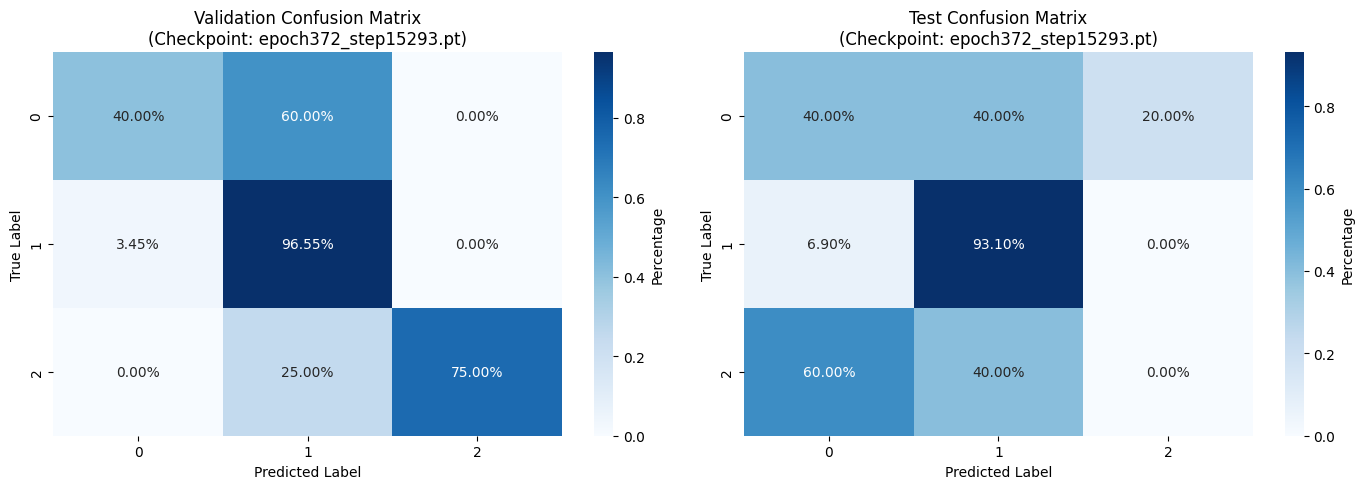


Validation Confusion Matrix (raw counts):
[[ 4  6  0]
 [ 1 28  0]
 [ 0  1  3]]

Test Confusion Matrix (raw counts):
[[ 4  4  2]
 [ 2 27  0]
 [ 3  2  0]]


In [21]:
# Function to plot confusion matrices
def plot_confusion_matrices(ckpt, task_name="RNA_Ligand", class_thresholds=None, labels=[0, 1, 2]):
    """
    Plot confusion matrices for validation and test sets for a given checkpoint.
    
    Parameters:
    -----------
    ckpt : str
        Path to the checkpoint
    task_name : str
        Name of the task
    class_thresholds : dict or None
        Class-specific thresholds to use (None for argmax)
    labels : list
        List of class labels
    """
    # Get results
    val_results = get_atomica_results(ckpt, task_name, "val", class_thresholds=class_thresholds, recompute=False)
    test_results = get_atomica_results(ckpt, task_name, "test", class_thresholds=class_thresholds, recompute=False)
    
    # Extract true labels and predictions
    y_val_true = np.stack(val_results['label'])
    y_val_pred = np.stack(val_results['pred'])
    y_test_true = np.stack(test_results['label'])
    y_test_pred = np.stack(test_results['pred'])
    
    # Compute confusion matrices
    cm_val = confusion_matrix(y_val_true, y_val_pred, labels=labels)
    cm_test = confusion_matrix(y_test_true, y_test_pred, labels=labels)
    
    # Normalize confusion matrices to show percentages
    cm_val_norm = cm_val.astype('float') / cm_val.sum(axis=1)[:, np.newaxis]
    cm_test_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot validation confusion matrix
    sns.heatmap(cm_val_norm, annot=True, fmt='.2%', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, ax=axes[0],
                cbar_kws={'label': 'Percentage'})
    axes[0].set_title(f'Validation Confusion Matrix\n(Checkpoint: {os.path.basename(ckpt)})')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('True Label')
    
    # Plot test confusion matrix
    sns.heatmap(cm_test_norm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[1],
                cbar_kws={'label': 'Percentage'})
    axes[1].set_title(f'Test Confusion Matrix\n(Checkpoint: {os.path.basename(ckpt)})')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')
    
    plt.tight_layout()
    plt.show()
    
    # Print raw counts
    print("\nValidation Confusion Matrix (raw counts):")
    print(cm_val)
    print("\nTest Confusion Matrix (raw counts):")
    print(cm_test)
    
    return cm_val, cm_test

# Plot confusion matrices for the best checkpoint
if len(all_metrics) > 0:
    best_ckpt = all_metrics.iloc[0]['ckpt']
    # Determine if thresholds were used
    thresholds_str = all_metrics.iloc[0]['thresholds']
    if thresholds_str != 'argmax':
        # Parse thresholds from string (format: "{0: 0.3, 1: 0.4, 2: 0.3}")
        class_thresholds = ast.literal_eval(thresholds_str)
    else:
        class_thresholds = None
    
    print(f"Plotting confusion matrices for best checkpoint: {os.path.basename(best_ckpt)}")
    print(f"Using thresholds: {thresholds_str}\n")
    plot_confusion_matrices(best_ckpt, class_thresholds=class_thresholds)

In [22]:
all_metrics.sort_values(by="val_f1_macro", ascending=False, inplace=True)
all_metrics['version'] = all_metrics['ckpt'].apply(lambda x: x.split("version_")[1] if "ensemble" not in x else "ensemble")
all_metrics['epoch'] = all_metrics['ckpt'].apply(lambda x: int(x.split("epoch")[1].split("_")[0]) if "ensemble" not in x else 0)
# all_metrics[all_metrics['epoch'] < 400]
all_metrics

,ckpt,thresholds,val_f1_macro,val_f1_micro,val_f1_weighted,val_0,val_1,val_2,test_f1_macro,test_f1_micro,test_f1_weighted,test_0,test_1,test_2,version,epoch
0,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,argmax,0.755159,0.813953,0.793882,0.533333,0.875000,0.857143,0.430673,0.704545,0.669741,0.421053,0.870968,0.000000,281/checkpoint/epoch372_step15293.pt,372
1,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,argmax,0.673315,0.813953,0.814116,0.714286,0.905660,0.400000,0.524109,0.772727,0.748428,0.666667,0.905660,0.000000,280/checkpoint/epoch360_step14801.pt,360
2,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,argmax,0.615873,0.604651,0.631229,0.514286,0.666667,0.666667,0.642496,0.681818,0.696994,0.606061,0.750000,0.571429,278/checkpoint/epoch378_step15539.pt,378
3,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,argmax,0.599301,0.674419,0.679468,0.454545,0.771930,0.571429,0.587430,0.727273,0.723799,0.592593,0.836364,0.333333,279/checkpoint/epoch363_step15652.pt,363
5,ensemble,argmax,0.575039,0.697674,0.689877,0.545455,0.779661,0.400000,0.601954,0.750000,0.742674,0.615385,0.857143,0.333333,ensemble,0
4,/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/ba...,argmax,0.517427,0.790698,0.764096,0.640000,0.912281,0.000000,0.446597,0.727273,0.686763,0.454545,0.885246,0.000000,276/checkpoint/epoch201_step8484.pt,201


In [23]:
all_metrics[all_metrics['ckpt'] != 'ensemble'][['test_f1_macro', 'test_f1_micro']].mean()

test_f1_macro    0.526261
test_f1_micro    0.722727
dtype: float64

In [23]:
all_metrics['ckpt'].tolist()

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_226/checkpoint/epoch296_step12177.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_233/checkpoint/epoch200_step8241.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_246/checkpoint/epoch170_step7353.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_257/checkpoint/epoch179_step7560.pt',
 'ensemble',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNA_Ligand/models/version_256/checkpoint/epoch190_step7831.pt']

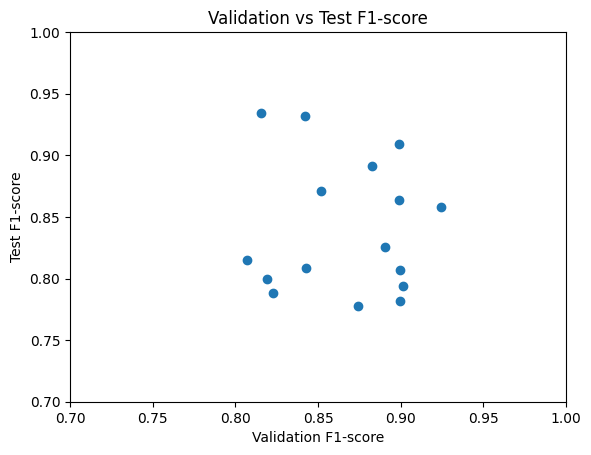

In [48]:
plt.scatter(all_metrics['val_f1_weighted'], all_metrics['test_f1_weighted'])
plt.xlim(0.7, 1)
plt.ylim(0.7, 1)
plt.xlabel("Validation F1-score")
plt.ylabel("Test F1-score")
plt.title("Validation vs Test F1-score")
plt.show()

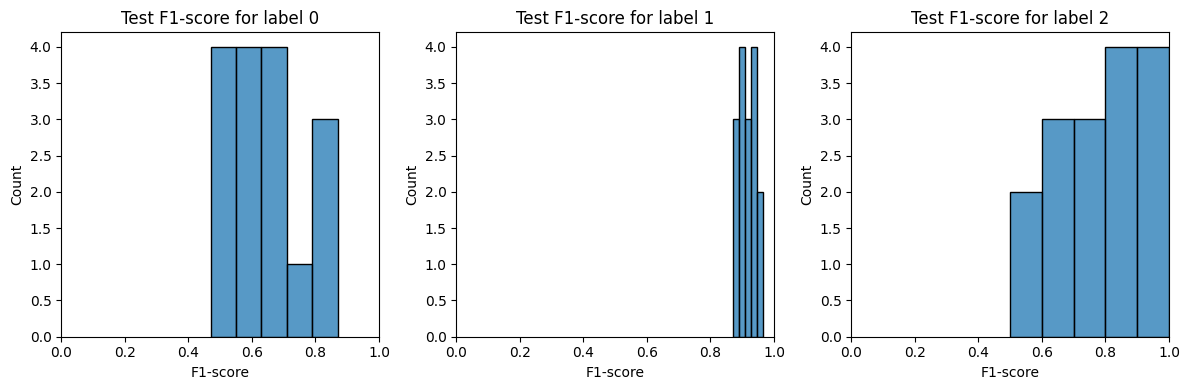

In [49]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))
for i, ax in enumerate(axes):
    sns.histplot(all_metrics[f"test_{i}"], ax=ax)
    ax.set_title(f"Test F1-score for label {i}")
    ax.set_xlabel("F1-score")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


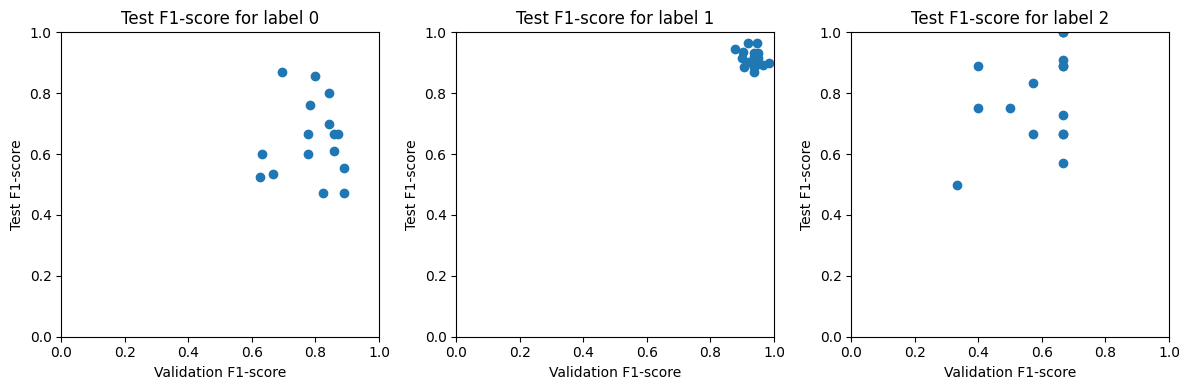

In [50]:
fig, axes = plt.subplots(1,3, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.scatter(all_metrics[f'val_{i}'], all_metrics[f'test_{i}'])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f"Test F1-score for label {i}")
    ax.set_xlabel("Validation F1-score")
    ax.set_ylabel("Test F1-score")
plt.tight_layout()
plt.show()

In [18]:
best_ckpts = all_metrics['ckpt'].tolist()
[best_ckpts[0], best_ckpts[1], best_ckpts[3]]

['/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_115/checkpoint/epoch269_step33480.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_91/checkpoint/epoch221_step27528.pt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/rnaglib_benchmark/RNAGo/models/version_88/checkpoint/epoch242_step30132.pt']

In [20]:
metrics.per_label

{0: {'precision': 0.24242424242424243,
  'recall': 1.0,
  'f1': 0.3902439024390244,
  'support': 8.0,
  'jaccard': 0.24242424242424243},
 1: {'precision': 1.0,
  'recall': 1.0,
  'f1': 1.0,
  'support': 7.0,
  'jaccard': 1.0},
 2: {'precision': 0.9,
  'recall': 0.8181818181818182,
  'f1': 0.8571428571428571,
  'support': 11.0,
  'jaccard': 0.75},
 3: {'precision': 0.125,
  'recall': 1.0,
  'f1': 0.2222222222222222,
  'support': 1.0,
  'jaccard': 0.125},
 4: {'precision': 1.0,
  'recall': 0.1,
  'f1': 0.18181818181818182,
  'support': 20.0,
  'jaccard': 0.1}}